In [1]:
# Import libraries
import numpy as np
import pandas as pd
import pyhf
import matplotlib.pyplot as plt

# Import Bayesian analysis libraries
from bayesian_pyhf import infer
import pymc as pm
import arviz as az
from scipy.stats import norm
from scipy.optimize import minimize
from scipy.integrate import cumulative_trapezoid
from scipy import optimize
            

/home/paul/miniforge3/envs/jupyterenv/lib/python3.12/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
nominal_eps = 1e-3
scaling = 0.05
fraction_outside = 1.1

# Target POT
target_pot_run1 = 2.2e20
target_pot_run3 = 5.02e20

# Masses to loop over
masses = ["0.01", "0.02", "0.03", "0.04", "0.05", "0.06", "0.07", "0.08", "0.09", "0.1", "0.2", "0.3", "0.4"]

# Meson scalings
meson_scalings = {"pi0": 11.7, "eta": 7.2}

# Correction factors
correction_dic_a = {
    "pi0": {'0.01': 11.198, '0.02': 11.145, '0.03': 10.861, '0.04': 11.543, '0.05': 10.671, 
            '0.06': 10.098, '0.07': 8.741, '0.08': 10.282, '0.09': 9.333},
    "eta": {'0.02': 10.555, '0.03': 9.759, '0.04': 7.934, '0.05': 9.387, '0.06': 9.863, 
            '0.07': 10.301, '0.08': 9.141, '0.09': 7.273, '0.1': 7.228, '0.2': 7.597, 
            '0.3': 5.219, '0.4': 4.498}
}

# Uncertainties
pot_uncert = 0.02  # 2% POT uncertainty
flux_uncert = 0.22  # 22% flux uncertainty
detvar_uncert = 0.18  # 18% detector variation uncertainty

# Cross-section uncertainties (%) 
run1_xsec_uncert_a = {
    "pi0": {"0.01": 1.16, "0.02": 2.27, "0.03": 3.48, "0.04": 4.48, "0.05": 5.50, 
            "0.06": 5.92, "0.07": 7.17, "0.08": 8.55, "0.09": 8.97},
    "eta": {"0.02": 2.09, "0.03": 3.50, "0.04": 4.33, "0.05": 6.07, "0.06": 6.26, 
            "0.07": 7.45, "0.08": 8.72, "0.09": 8.99, "0.1": 9.63, "0.2": 18.95, 
            "0.3": 22.04, "0.4": 30.34}
}

run3_xsec_uncert_a = {
    "pi0": {"0.01": 0.92, "0.02": 2.32, "0.03": 2.82, "0.04": 4.32, "0.05": 5.24, 
            "0.06": 5.93, "0.07": 6.44, "0.08": 8.94, "0.09": 7.84},
    "eta": {"0.02": 2.15, "0.03": 3.24, "0.04": 4.14, "0.05": 5.41, "0.06": 7.17, 
            "0.07": 6.41, "0.08": 7.87, "0.09": 8.32, "0.1": 9.22, "0.2": 15.78, 
            "0.3": 20.14, "0.4": 23.64}
}

# total_pot values
total_pot = {
    "run1_dt_ratio_0.6_ma_0.01_pi0": 3.583299e+20,
    "run1_dt_ratio_0.6_ma_0.02_eta": 1.971339e+22,
    "run1_dt_ratio_0.6_ma_0.02_pi0": 3.785739e+21,
    "run1_dt_ratio_0.6_ma_0.03_eta": 6.018737e+22,
    "run1_dt_ratio_0.6_ma_0.03_pi0": 1.403744e+22,
    "run1_dt_ratio_0.6_ma_0.04_eta": 2.797252e+23,
    "run1_dt_ratio_0.6_ma_0.04_pi0": 6.144923e+22,
    "run1_dt_ratio_0.6_ma_0.05_eta": 6.491310e+23,
    "run1_dt_ratio_0.6_ma_0.05_pi0": 1.594137e+23,
    "run1_dt_ratio_0.6_ma_0.06_eta": 1.333156e+24,
    "run1_dt_ratio_0.6_ma_0.06_pi0": 5.428614e+23,
    "run1_dt_ratio_0.6_ma_0.07_eta": 1.726805e+24,
    "run1_dt_ratio_0.6_ma_0.07_pi0": 2.122624e+24,
    "run1_dt_ratio_0.6_ma_0.08_eta": 3.721201e+24,
    "run1_dt_ratio_0.6_ma_0.08_pi0": 9.137349e+24,
    "run1_dt_ratio_0.6_ma_0.09_eta": 6.937703e+24,
    "run1_dt_ratio_0.6_ma_0.09_pi0": 4.752829e+25,
    "run1_dt_ratio_0.6_ma_0.1_eta": 2.632356e+25,
    "run1_dt_ratio_0.6_ma_0.2_eta": 2.642929e+27,
    "run1_dt_ratio_0.6_ma_0.3_eta": 4.548050e+29,
    "run1_dt_ratio_0.6_ma_0.4_eta": 2.856632e+32,
    "run3_dt_ratio_0.6_ma_0.01_pi0": 7.825758e+20,
    "run3_dt_ratio_0.6_ma_0.02_eta": 2.618067e+22,
    "run3_dt_ratio_0.6_ma_0.02_pi0": 3.553433e+21,
    "run3_dt_ratio_0.6_ma_0.03_eta": 1.076195e+23,
    "run3_dt_ratio_0.6_ma_0.03_pi0": 1.590684e+22,
    "run3_dt_ratio_0.6_ma_0.04_eta": 3.182032e+23,
    "run3_dt_ratio_0.6_ma_0.04_pi0": 6.326536e+22,
    "run3_dt_ratio_0.6_ma_0.05_eta": 1.458703e+24,
    "run3_dt_ratio_0.6_ma_0.05_pi0": 3.951992e+23,
    "run3_dt_ratio_0.6_ma_0.06_eta": 1.106334e+24,
    "run3_dt_ratio_0.6_ma_0.06_pi0": 8.377697e+23,
    "run3_dt_ratio_0.6_ma_0.07_eta": 3.539695e+24,
    "run3_dt_ratio_0.6_ma_0.07_pi0": 2.825310e+24,
    "run3_dt_ratio_0.6_ma_0.08_eta": 4.752001e+24,
    "run3_dt_ratio_0.6_ma_0.08_pi0": 1.088737e+25,
    "run3_dt_ratio_0.6_ma_0.09_eta": 8.286352e+24,
    "run3_dt_ratio_0.6_ma_0.09_pi0": 7.609472e+25,
    "run3_dt_ratio_0.6_ma_0.1_eta": 1.655501e+25,
    "run3_dt_ratio_0.6_ma_0.2_eta": 2.472610e+27,
    "run3_dt_ratio_0.6_ma_0.3_eta": 2.116252e+29,
    "run3_dt_ratio_0.6_ma_0.4_eta": 3.486213e+32,
}

# Background scalings Background POT
scalings_run1 = {"nu": 1.0/2.35e21, "dirt": 1.026*0.75/1.6e21, "beamoff": 0.98*(5736147/9186361.390000)}
scalings_run3 = {"nu": 1.0/1.993661e21, "dirt": 1.0*0.35/1.020e21, "beamoff": 0.98*(10385459.0/34147459.925000)}

In [3]:
# Directories
base_dir_run1 = "/home/paul/Msci/dm_sets/run1_samples/"
base_dir_run3 = "/home/paul/Msci/dm_sets/run3_samples/"
signal_dir_run1 = "/home/paul/Msci/dm_sets/run1_signal/"
signal_dir_run3 = "/home/paul/Msci/dm_sets/run3_signal/"

# Background
df_nu_run1 = pd.read_csv(base_dir_run1 + "run1_nu_overlay_merged_with_weights.csv").drop_duplicates()
df_nu_run3 = pd.read_csv(base_dir_run3 + "run3_nu_overlay_merged_with_weights.csv").drop_duplicates()
df_dirt_run1 = pd.read_csv(base_dir_run1 + "run1_dirt_merged_with_weights.csv").drop_duplicates()
df_dirt_run3 = pd.read_csv(base_dir_run3 + "run3_dirt_merged_with_weights.csv").drop_duplicates()
df_offbeam_run1 = pd.read_csv(base_dir_run1 + "run1_offbeam_larcv_cropped_full_set_scores.csv").drop_duplicates()
df_offbeam_run3 = pd.read_csv(base_dir_run3 + "run3_offbeam_larcv_cropped_scores.csv").drop_duplicates()

print(f"Run 1 backgrounds - Nu: {len(df_nu_run1)}, Dirt: {len(df_dirt_run1)}, Offbeam: {len(df_offbeam_run1)}")
print(f"Run 3 backgrounds - Nu: {len(df_nu_run3)}, Dirt: {len(df_dirt_run3)}, Offbeam: {len(df_offbeam_run3)}")

# Real data

data_run1 = pd.read_csv('/home/paul/Msci/dm_sets/run_data/run1_NuMI_beamon_larcv_cropped_full_set_scores.csv')
data_run3 = pd.read_csv('/home/paul/Msci/dm_sets/run_data/run3_NuMI_beamon_larcv_cropped_full_set_scores.csv')



# Logit transform function
def logit_transform(score):
    return np.log(score / (1 - score))

# Luis's bins in logit space (signal region only: score >= 0.5 means logit >= 0)
bins = [ 0., 1.375, 2.75, 4.125, 5.5, 6.875]

# Filter to signal region (score >= 0.5) then apply logit
df_nu_run1_sr = df_nu_run1[df_nu_run1['signal_score'] >= 0.5].copy()
df_nu_run3_sr = df_nu_run3[df_nu_run3['signal_score'] >= 0.5].copy()
df_dirt_run1_sr = df_dirt_run1[df_dirt_run1['signal_score'] >= 0.5].copy()
df_dirt_run3_sr = df_dirt_run3[df_dirt_run3['signal_score'] >= 0.5].copy()
df_offbeam_run1_sr = df_offbeam_run1[df_offbeam_run1['signal_score'] >= 0.5].copy()
df_offbeam_run3_sr = df_offbeam_run3[df_offbeam_run3['signal_score'] >= 0.5].copy()
data_run1_sr = data_run1[data_run1['signal_score'] >= 0.5].copy()
data_run3_sr = data_run3[data_run3['signal_score'] >= 0.5].copy()

# Apply logit transform
df_nu_run1_sr['logit_score'] = logit_transform(df_nu_run1_sr['signal_score'])
df_nu_run3_sr['logit_score'] = logit_transform(df_nu_run3_sr['signal_score'])
df_dirt_run1_sr['logit_score'] = logit_transform(df_dirt_run1_sr['signal_score'])
df_dirt_run3_sr['logit_score'] = logit_transform(df_dirt_run3_sr['signal_score'])
df_offbeam_run1_sr['logit_score'] = logit_transform(df_offbeam_run1_sr['signal_score'])
df_offbeam_run3_sr['logit_score'] = logit_transform(df_offbeam_run3_sr['signal_score'])
data_run1_sr['logit_score'] = logit_transform(data_run1_sr['signal_score'])
data_run3_sr['logit_score'] = logit_transform(data_run3_sr['signal_score'])

# Histogram data in logit space
hist_data_run1, _ = np.histogram(data_run1_sr['logit_score'], bins=bins)
hist_data_run3, _ = np.histogram(data_run3_sr['logit_score'], bins=bins)

Run 1 backgrounds - Nu: 13770, Dirt: 3331, Offbeam: 3889
Run 3 backgrounds - Nu: 11526, Dirt: 2413, Offbeam: 15479


In [4]:
# Background scalings
nu_scaling_run1 = target_pot_run1 * scalings_run1["nu"]
nu_scaling_run3 = target_pot_run3 * scalings_run3["nu"]
dirt_scaling_run1 = target_pot_run1 * scalings_run1["dirt"]
dirt_scaling_run3 = target_pot_run3 * scalings_run3["dirt"]
offbeam_scaling_run1 = scalings_run1["beamoff"]
offbeam_scaling_run3 = scalings_run3["beamoff"]

# Background histograms in logit space
hist_nu_run1, _ = np.histogram(df_nu_run1_sr['logit_score'], bins=bins, weights=df_nu_run1_sr['weight'])
hist_nu_run3, _ = np.histogram(df_nu_run3_sr['logit_score'], bins=bins, weights=df_nu_run3_sr['weight'])
hist_dirt_run1, _ = np.histogram(df_dirt_run1_sr['logit_score'], bins=bins, weights=df_dirt_run1_sr['weight'])
hist_dirt_run3, _ = np.histogram(df_dirt_run3_sr['logit_score'], bins=bins, weights=df_dirt_run3_sr['weight'])
hist_offbeam_run1, _ = np.histogram(df_offbeam_run1_sr['logit_score'], bins=bins)
hist_offbeam_run3, _ = np.histogram(df_offbeam_run3_sr['logit_score'], bins=bins)

# Apply scalings
hist_nu_run1 = hist_nu_run1 * nu_scaling_run1
hist_nu_run3 = hist_nu_run3 * nu_scaling_run3
hist_dirt_run1 = hist_dirt_run1 * dirt_scaling_run1
hist_dirt_run3 = hist_dirt_run3 * dirt_scaling_run3
hist_offbeam_run1 = hist_offbeam_run1 * offbeam_scaling_run1
hist_offbeam_run3 = hist_offbeam_run3 * offbeam_scaling_run3

hist_bkg_run1 = hist_nu_run1 + hist_dirt_run1 + hist_offbeam_run1
hist_bkg_run3 = hist_nu_run3 + hist_dirt_run3 + hist_offbeam_run3

n_bkg = hist_bkg_run1.tolist() + hist_bkg_run3.tolist()

# n_data = n_bkg.copy()  # (Asimov set, use when no data)
n_data = hist_data_run1.tolist() + hist_data_run3.tolist()

# Background uncertainties (statistical only for now)
bkg_uncert_run1 = np.sqrt(hist_bkg_run1)
bkg_uncert_run3 = np.sqrt(hist_bkg_run3)
# Ensure no zeros
bkg_uncert_run1 = np.maximum(bkg_uncert_run1, 0.01 * hist_bkg_run1 + 0.001)
bkg_uncert_run3 = np.maximum(bkg_uncert_run3, 0.01 * hist_bkg_run3 + 0.001)
sigma_bkg = bkg_uncert_run1.tolist() + bkg_uncert_run3.tolist()

total_bkg_run1 = np.sum(hist_bkg_run1)
total_bkg_run3 = np.sum(hist_bkg_run3)

print(f"Background Run1: {total_bkg_run1:.2f}")
print(f"Background Run3: {total_bkg_run3:.2f}")
print(f"Background Total: {sum(n_bkg):.2f}")
print(f"Data Total: {sum(n_data)}")

Background Run1: 75.10
Background Run3: 184.42
Background Total: 259.52
Data Total: 196


In [5]:
def get_signal_scaling(run, mass, dmode):
    """Calculate signal scaling for a given run, mass, and decay mode."""
    key = f"{run}_dt_ratio_0.6_ma_{mass}_{dmode}"
    pot = total_pot[key]
    target = target_pot_run1 if run == "run1" else target_pot_run3
    
    # Base scaling: meson_scaling * target_pot * correction term / total_pot NEED FRACTIONAL
    scale = meson_scalings[dmode] * target * correction_dic_a[dmode][mass] / pot
    return scale

In [6]:
def load_signal_for_mass(mass):
    """Load signal for a given mass, combining pi0 and eta as needed."""
    
    hist_signal_run1 = np.zeros(len(bins) - 1)
    hist_signal_run3 = np.zeros(len(bins) - 1)
    
    # Determine which decay modes to use
    if mass == "0.01":
        decay_modes = ["pi0"]
    elif float(mass) >= 0.1:
        decay_modes = ["eta"]
    else:
        decay_modes = ["pi0", "eta"]
    
    for dmode in decay_modes:
        # Run 1
        try:
            fname_run1 = f"{signal_dir_run1}run1_dt_ratio_0.6_ma_{mass}_{dmode}_larcv_cropped_scores.csv"
            df = pd.read_csv(fname_run1).drop_duplicates()
            # Filter to signal region and apply logit
            df_sr = df[df['signal_score'] >= 0.5].copy()
            df_sr['logit_score'] = logit_transform(df_sr['signal_score'])
            scale = get_signal_scaling("run1", mass, dmode)
            hist, _ = np.histogram(df_sr['logit_score'], bins=bins)
            hist_signal_run1 += hist * scale
        except FileNotFoundError:
            print(f"  Warning: {fname_run1} not found")
        
        # Run 3
        try:
            fname_run3 = f"{signal_dir_run3}run3_dt_ratio_0.6_ma_{mass}_{dmode}_larcv_cropped_scores.csv"
            df = pd.read_csv(fname_run3).drop_duplicates()
            # Filter to signal region and apply logit
            df_sr = df[df['signal_score'] >= 0.5].copy()
            df_sr['logit_score'] = logit_transform(df_sr['signal_score'])
            scale = get_signal_scaling("run3", mass, dmode)
            hist, _ = np.histogram(df_sr['logit_score'], bins=bins)
            hist_signal_run3 += hist * scale
        except FileNotFoundError:
            print(f"  Warning: {fname_run3} not found")
    
    return hist_signal_run1, hist_signal_run3

In [7]:
# Store results
results_list = []

for mass in masses:
    print(f"\n{'='*60}")
    print(f"Processing mass: {mass}")
    print(f"{'='*60}")
    
    # Load signal for this mass
    hist_signal_run1, hist_signal_run3 = load_signal_for_mass(mass)
    
    total_sig_run1 = np.sum(hist_signal_run1)
    total_sig_run3 = np.sum(hist_signal_run3)
    
    print(f"Signal Run1: {total_sig_run1:.2f}")
    print(f"Signal Run3: {total_sig_run3:.2f}")

    # Calculate cross-section uncertainty for this mass
    xsec_uncert_sq = 0
    if mass == "0.01":
        decay_modes = ["pi0"]
    elif float(mass) >= 0.1:
        decay_modes = ["eta"]
    else:
        decay_modes = ["pi0", "eta"]
    
    for dmode in decay_modes:
        if dmode in run1_xsec_uncert_a and mass in run1_xsec_uncert_a[dmode]:
            xsec_uncert_sq += run1_xsec_uncert_a[dmode][mass]**2
    
    xsec_uncert = np.sqrt(xsec_uncert_sq) / 100
    print(f"Cross-section uncertainty: {xsec_uncert:.1%}")
    
    # Combine runs
    n_sig = hist_signal_run1.tolist() + hist_signal_run3.tolist()
    
    # Luis's factor calculation
    factor = scaling * (((total_bkg_run1/total_sig_run1) + (total_bkg_run3/total_sig_run3)) / 2.)
    print(f"Scaling factor: {factor:.6e}")
    
    # Scale signal
    n_sig_scaled = [s * factor * fraction_outside for s in n_sig]
    
    # Build pyhf model with syst
    model = pyhf.Model({
        "channels": [{
            "name": "singlechannel",
            "samples": [
                {
                    "name": "signal",
                    "data": n_sig_scaled,
                    "modifiers": [
                        {"name": "mu", "type": "normfactor", "data": None},
                        {"name": "pot_uncert", "type": "normsys", "data": {"hi": 1.02, "lo": 0.98}},
                        {"name": "flux_uncert", "type": "normsys", "data": {"hi": 1.22, "lo": 0.78}},
                        {"name": "det_uncert", "type": "normsys", "data": {"hi": 1.18, "lo": 0.82}},
                        {"name": "xsec_uncert", "type": "normsys", "data": {"hi": 1 + xsec_uncert, "lo": 1 - xsec_uncert}},
                    ]
                },
                {
                    "name": "background",
                    "data": n_bkg,
                    "modifiers": [
                        {"name": "pot_uncert", "type": "normsys", "data": {"hi": 1.02, "lo": 0.98}},
                    ]
                }
            ]
        }]
    })
    
    # Frequentist
    poi_values = np.linspace(0., 10., 100)
    try:
        obs = n_data + model.config.auxdata
        obs_limit, exp_limits, (scan, res) = pyhf.infer.intervals.upper_limits.upper_limit(
            obs, model, poi_values, level=0.1, return_results=True)
        
        # Convert to epsilon^2
        obs_epsilon = (nominal_eps**2) * np.sqrt(obs_limit * factor)
        exp_epsilon = (nominal_eps**2) * np.sqrt(exp_limits[2] * factor)
        
        print(f"  Frequentist upper limit (obs): μ = {obs_limit:.4f}")
        print(f"  Frequentist upper limit (obs): ε² = {obs_epsilon:.2e}")
        
        results_list.append({
            'mass': float(mass),
            'mu_obs': obs_limit,
            'mu_exp': exp_limits[2],
            'epsilon_squared_obs': obs_epsilon,
            'epsilon_squared_exp': exp_epsilon,
            'factor': factor
        })
        
    except Exception as e:
        print(f"  Frequentist error for mass {mass}: {e}")

# Bayesian approach 
    try:
        # Define prior for μ (flat prior from 0 to 10)
        unconstr_priors = {
            'mu': {'type': 'Uniform_Unconstrained', 'lower': [0.], 'upper': [10.]},
        }
        
        n_draws = 2000
        
        # Run MCMC sampling (with predictives for diagnostic plots)
        with infer.model(model, unconstr_priors, n_data):
            step = pm.Metropolis()
            post_data = pm.sample(draws=n_draws, tune=500, chains=2, step=step, progressbar=False)
            post_pred = pm.sample_posterior_predictive(post_data)
            prior_pred = pm.sample_prior_predictive(n_draws)
        
        # Extract μ samples from posterior
        mu_samples = post_data.posterior['mu'].values.flatten()
        
        # Calculate credible intervals
        mu_median_bayes = np.median(mu_samples)
        mu_90_bayes = np.percentile(mu_samples, 90)
        
        # Convert to ε²
        obs_epsilon_bayes = (nominal_eps**2) * np.sqrt(mu_90_bayes * factor)
        
        # Store results (including objects for plotting)
        results_list[-1]['mu_median_bayes'] = mu_median_bayes
        results_list[-1]['mu_90_bayes'] = mu_90_bayes
        results_list[-1]['epsilon_squared_90_bayes'] = obs_epsilon_bayes
        results_list[-1]['post_data'] = post_data
        results_list[-1]['post_pred'] = post_pred
        results_list[-1]['prior_pred'] = prior_pred
        results_list[-1]['model'] = model
        
        print(f"  Bayesian 90% credible limit: μ = {mu_90_bayes:.4f}")
        print(f"  Bayesian 90% credible limit: ε² = {obs_epsilon_bayes:.2e}")

    except Exception as e:
        print(f"  Bayesian error for mass {mass}: {e}")


Processing mass: 0.01
Signal Run1: 253462.88
Signal Run3: 555442.85
Cross-section uncertainty: 1.2%
Scaling factor: 1.570829e-05
  Frequentist upper limit (obs): μ = 0.8193
  Frequentist upper limit (obs): ε² = 3.59e-09


Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>Metropolis: [mu]
>Metropolis: [pot_uncert]
>Metropolis: [det_uncert]
>Metropolis: [flux_uncert]
>Metropolis: [xsec_uncert]
Sampling 2 chains for 500 tune and 2_000 draw iterations (1_000 + 4_000 draws total) took 5 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [Expected_Data]


Output()

Sampling: [Expected_Data, det_uncert, flux_uncert, mu, pot_uncert, xsec_uncert]


  Bayesian 90% credible limit: μ = 0.8060
  Bayesian 90% credible limit: ε² = 3.56e-09

Processing mass: 0.02
Signal Run1: 35852.16
Signal Run3: 89490.93
Cross-section uncertainty: 3.1%
Scaling factor: 1.038894e-04


...

  Bayesian 90% credible limit: μ = 0.9997
  Bayesian 90% credible limit: ε² = 1.80e-04

Processing mass: 0.4
Signal Run1: 0.00
Signal Run3: 0.00
Cross-section uncertainty: 30.3%
Scaling factor: 8.011043e+08
  Frequentist upper limit (obs): μ = 0.0916
  Frequentist upper limit (obs): ε² = 8.57e-03


Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>Metropolis: [mu]
>Metropolis: [pot_uncert]
>Metropolis: [det_uncert]
>Metropolis: [flux_uncert]
>Metropolis: [xsec_uncert]
Sampling 2 chains for 500 tune and 2_000 draw iterations (1_000 + 4_000 draws total) took 5 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [Expected_Data]


Output()

Sampling: [Expected_Data, det_uncert, flux_uncert, mu, pot_uncert, xsec_uncert]


  Bayesian 90% credible limit: μ = 0.0472
  Bayesian 90% credible limit: ε² = 6.15e-03


In [8]:
# Create dataframe and save
df_results = pd.DataFrame(results_list)
df_results = df_results.sort_values('mass')
print(df_results)

# Save to CSV
df_results.to_csv("/home/paul/Msci/plots/sensitivity/sensitivity_results.csv", index=False)
print("\nSaved to sensitivity_results.csv")

    mass               mu_obs               mu_exp  epsilon_squared_obs  \
0   0.01   0.8192671574058372    1.903090883007855         3.587379e-09   
1   0.02   0.7857539807898202   1.8099034033632266         9.035015e-09   
2   0.03    0.737441060475179   1.6806702075698539         1.924600e-08   
3   0.04   0.8030884935428609    1.732565631421536         3.846303e-08   
4   0.05     0.77629888336474    1.592366286744185         6.876842e-08   
5   0.06   0.8058745683268668    1.729696985416489         1.270669e-07   
6   0.07   0.8284306804680415   1.7528004039221572         2.434553e-07   
7   0.08   0.7982591898523331   1.7173159859837834         3.889448e-07   
8   0.09   0.7858581105897615   1.6938331874438104         6.842437e-07   
9   0.10   0.8048469077963649    1.731842917053631         1.057340e-06   
10  0.20   0.8100947673508689   1.9445345900760427         1.351177e-05   
11  0.30   0.8567970313003697   2.1124377242688226         1.670138e-04   
12  0.40  0.0916083010273

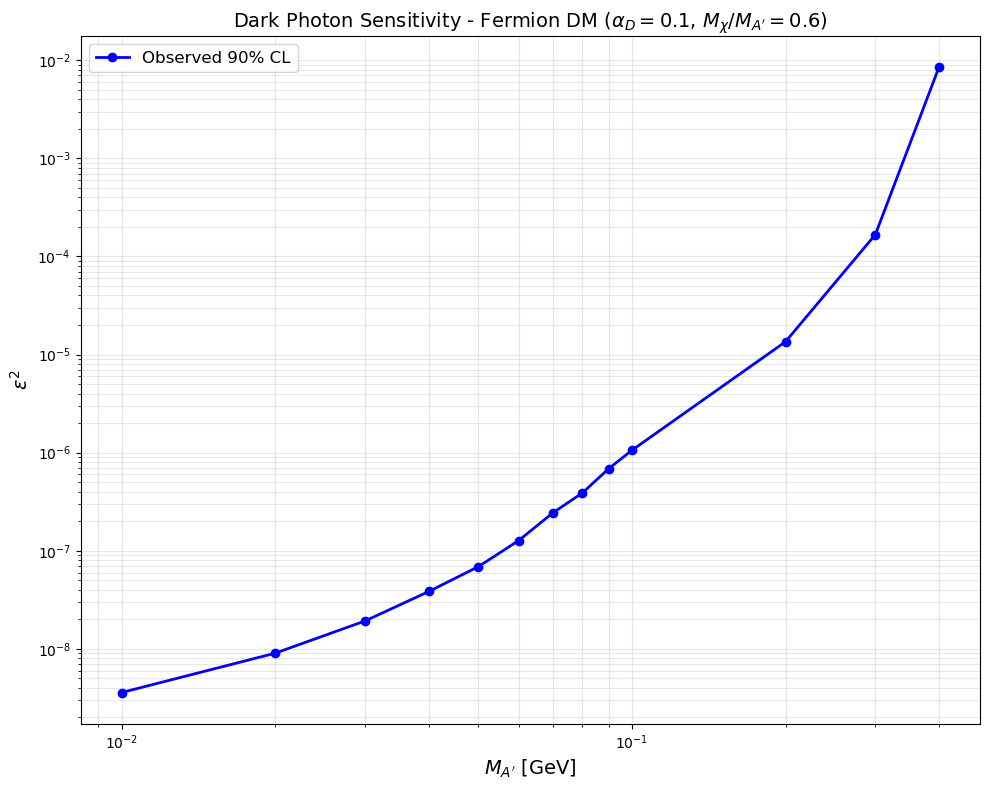

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(df_results['mass'], df_results['epsilon_squared_obs'], 'b-o', lw=2, label='Observed 90% CL')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$M_{A^\prime}$ [GeV]', fontsize=14)
ax.set_ylabel(r'$\epsilon^2$', fontsize=14)
ax.set_title(r'Dark Photon Sensitivity - Fermion DM ($\alpha_D = 0.1$, $M_\chi/M_{A^\prime} = 0.6$)', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig("/home/paul/Msci/plots/sensitivity_curve.png", dpi=300)
plt.savefig("/home/paul/Msci/plots/sensitivity_curve.pdf")
plt.show()

/tmp/ipykernel_9135/2807402148.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


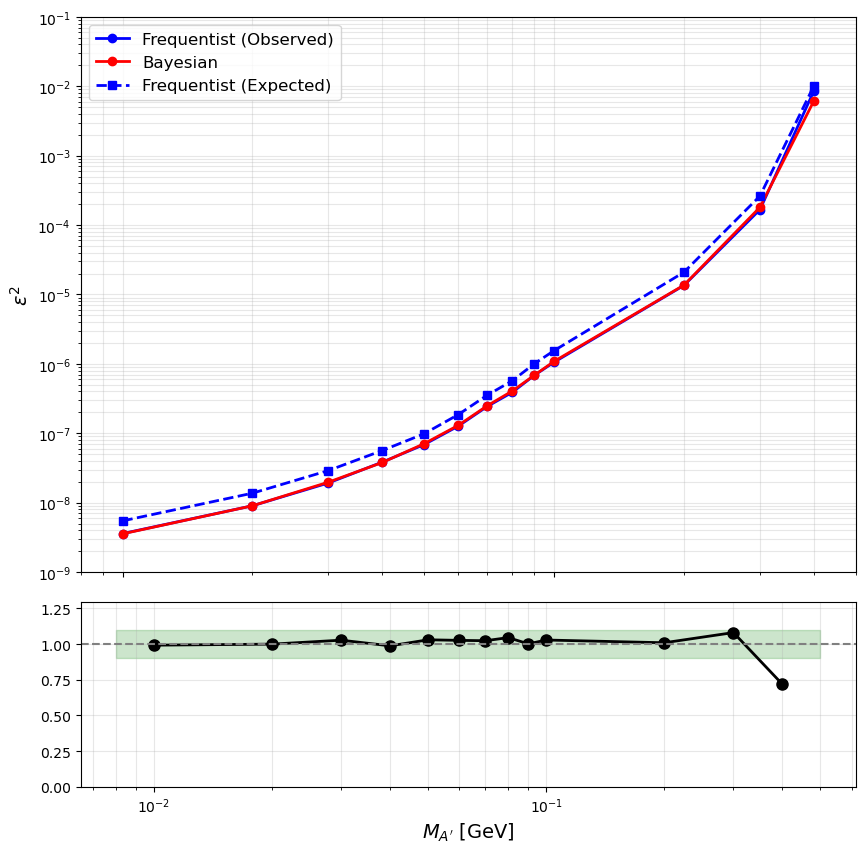

In [16]:
fig, ax = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08})

ax[0].plot(df_results['mass'], df_results['epsilon_squared_obs'], 'b-o', lw=2, label='Frequentist (Observed)')
ax[0].plot(df_results['mass'], df_results['epsilon_squared_90_bayes'], 'r-o', lw=2, label='Bayesian')
ax[0].plot(df_results['mass'], df_results['epsilon_squared_exp'], 'b--s', lw=2, label='Frequentist (Expected)')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_ylabel(r'$\varepsilon^2$', fontsize=14)
ax[0].legend(fontsize=12)
ax[0].grid(True, alpha=0.3, which='both')
ax[0].set_xlim(0.008, 0.5)
ax[0].set_ylim(1e-9, 1e-1)
ax[0].tick_params(axis='x', labelbottom=False)

frequentist = df_results['epsilon_squared_obs'].values
bayesian = df_results['epsilon_squared_90_bayes'].values
ratio = bayesian/frequentist

ax[1].plot(df_results['mass'], ratio, 'ko-', lw=2, markersize=8)
ax[1].axhline(1.0, color='gray', linestyle='--', linewidth=1.5)
ax[1].fill_between([0.008, 0.5], 0.9, 1.1, color='green', alpha=0.2, label='±10%')
ax[1].set_xscale('log')
ax[1].set_xlabel(r'$M_{A^\prime}$ [GeV]', fontsize=14)
ax[1].set_ylim(0, max(ratio) * 1.2)
ax[1].grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig("/home/paul/Msci/plots/sensitivity_curve.png", dpi=300)
plt.show()

Diagnostic plots for mass = 0.05 GeV


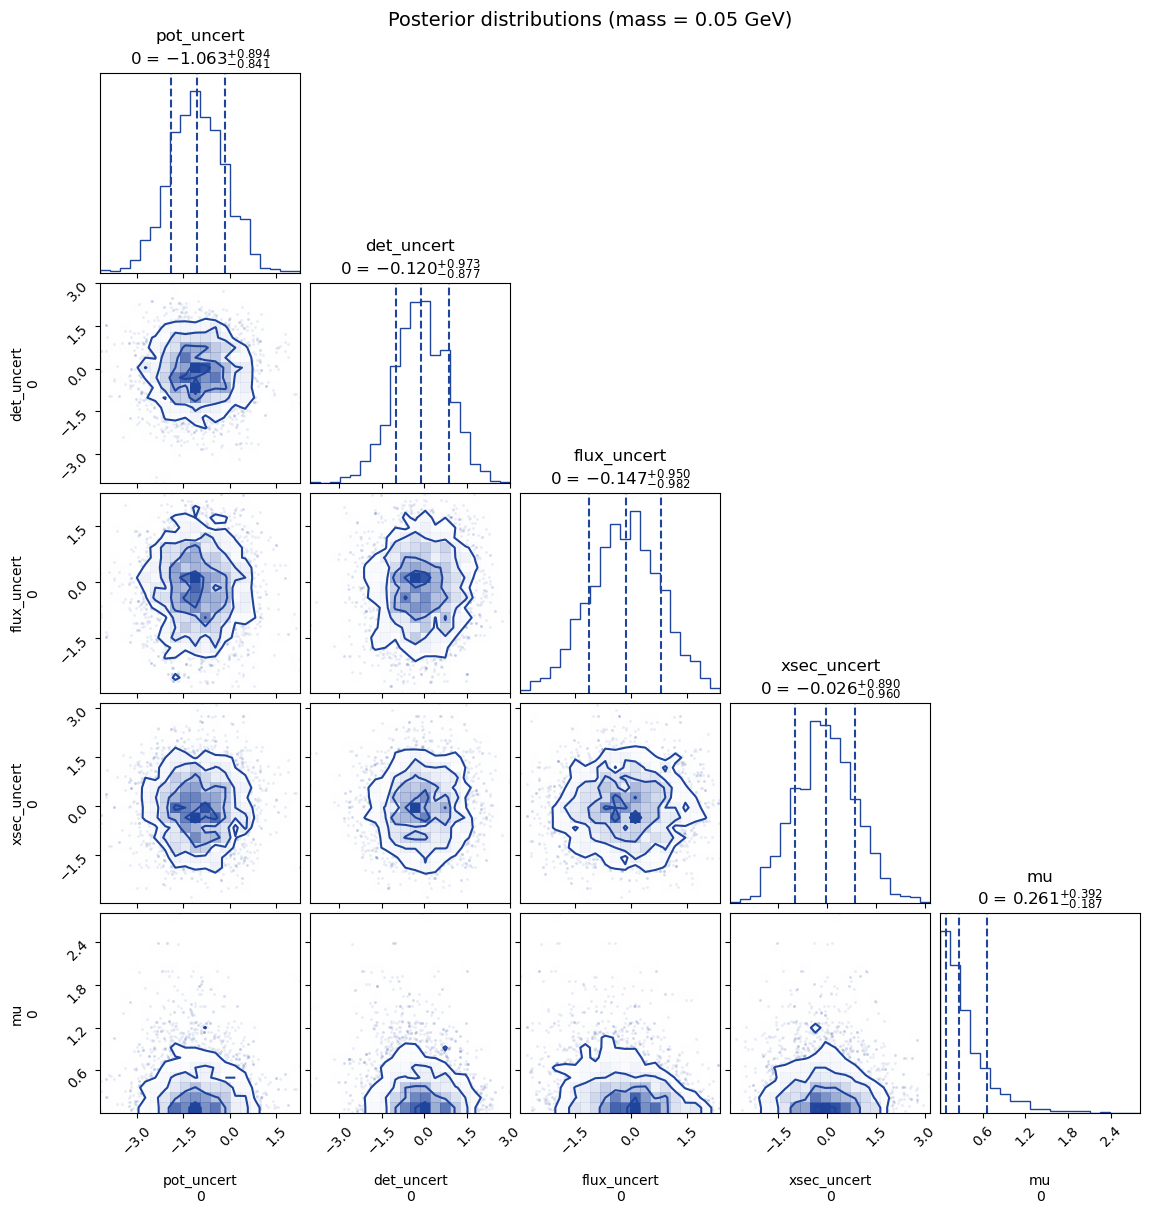

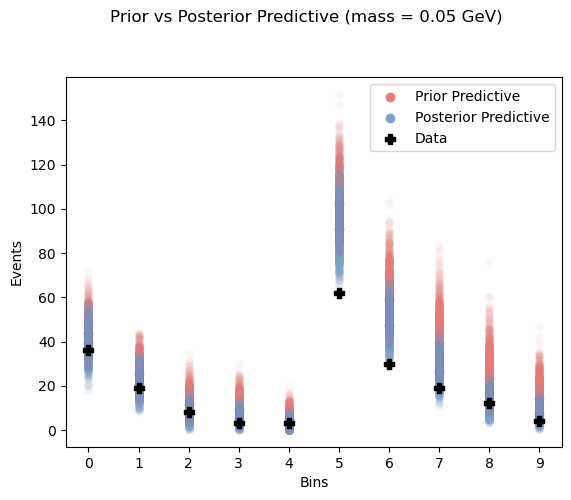

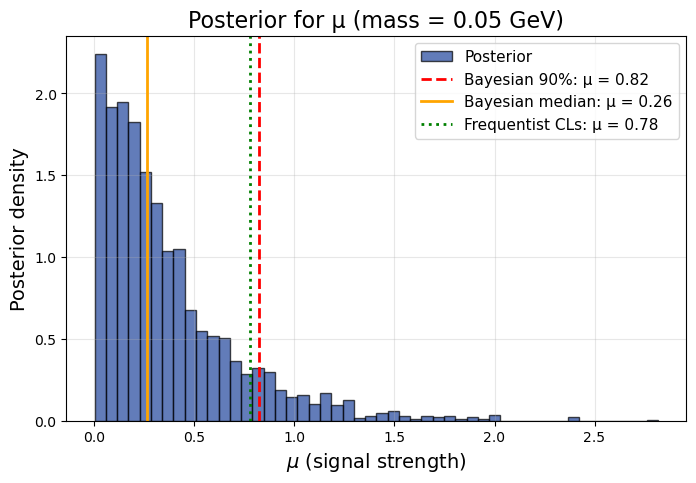


Summary for mass = 0.05 GeV:
  Frequentist CLs 90% limit: μ = 0.7763
  Bayesian 90% credible:     μ = 0.8230
  Ratio (Bayes/Freq):        1.060


In [11]:
import corner
from bayesian_pyhf import plotting

idx = 4  # Mass
r = results_list[idx]

print(f"Diagnostic plots for mass = {r['mass']} GeV")
print("="*50)

# Corner plot
fig = corner.corner(
    r['post_data'].posterior, 
    quantiles=[0.16, 0.5, 0.84],  # Show median and 68% interval
    show_titles=True,
    title_fmt='.3f',
    color='#1F449C'
)
fig.suptitle(f"Posterior distributions (mass = {r['mass']} GeV)", y=1.02, fontsize=14)
plt.savefig(f"corner_mass_{r['mass']}.png", dpi=150, bbox_inches='tight')
plt.show()

# Prior vs Posterior
plotting.prior_posterior_predictives(r['model'], n_data, r['post_pred'], r['prior_pred'], 1)
plt.suptitle(f"Prior vs Posterior Predictive (mass = {r['mass']} GeV)", y=1.02)
plt.savefig(f"predictives_mass_{r['mass']}.png", dpi=150, bbox_inches='tight')
plt.show()

# Mu posterior 
mu_samples = r['post_data'].posterior['mu'].values.flatten()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(mu_samples, bins=50, density=True, alpha=0.7, color='#1F449C', edgecolor='black', label='Posterior')
ax.axvline(r['mu_90_bayes'], color='red', linestyle='--', linewidth=2, label=f'Bayesian 90%: μ = {r["mu_90_bayes"]:.2f}')
ax.axvline(r['mu_median_bayes'], color='orange', linestyle='-', linewidth=2, label=f'Bayesian median: μ = {r["mu_median_bayes"]:.2f}')
ax.axvline(r['mu_obs'], color='green', linestyle=':', linewidth=2, label=f'Frequentist CLs: μ = {r["mu_obs"]:.2f}')
ax.set_xlabel(r'$\mu$ (signal strength)', fontsize=14)
ax.set_ylabel('Posterior density', fontsize=14)
ax.set_title(f'Posterior for μ (mass = {r["mass"]} GeV)', fontsize=16)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.savefig(f"mu_posterior_mass_{r['mass']}.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSummary for mass = {r['mass']} GeV:")
print(f"  Frequentist CLs 90% limit: μ = {r['mu_obs']:.4f}")
print(f"  Bayesian 90% credible:     μ = {r['mu_90_bayes']:.4f}")
print(f"  Ratio (Bayes/Freq):        {r['mu_90_bayes']/r['mu_obs']:.3f}")

/tmp/ipykernel_9135/2232538851.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


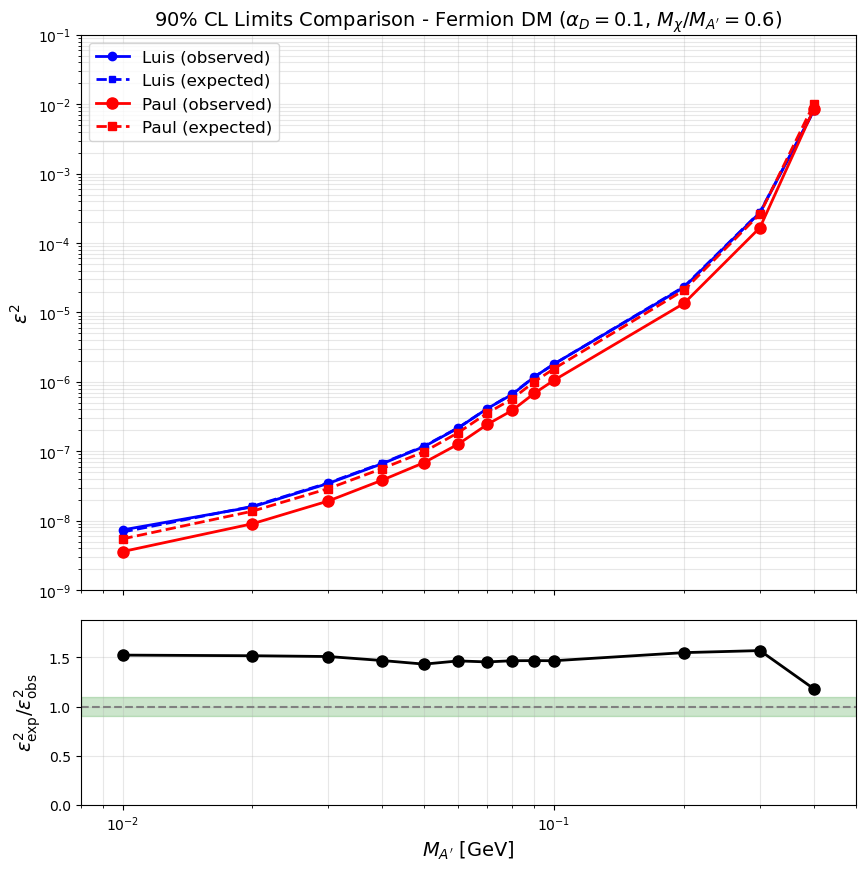

In [12]:
# Luis's values - Fermion DM, alpha_D = 0.1, M_chi/M_A' = 0.6 (Table 11.2)
luis_mass = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400])  # MeV
luis_observed = np.array([7.36e-9, 1.58e-8, 3.45e-8, 6.64e-8, 1.17e-7, 2.17e-7, 
                          4.12e-7, 6.61e-7, 1.18e-6, 1.81e-6, 2.30e-5, 2.75e-4, 8.13e-3])
luis_expected = np.array([6.86e-9, 1.61e-8, 3.51e-8, 6.74e-8, 1.19e-7, 2.19e-7,
                          4.12e-7, 6.72e-7, 1.18e-6, 1.81e-6, 2.35e-5, 2.80e-4, 8.09e-3])

luis_mass_gev = luis_mass / 1000.0

paul_mass_gev = df_results['mass'].values
paul_observed = df_results['epsilon_squared_obs'].values
paul_expected = df_results['epsilon_squared_exp'].values
ratio = paul_expected / paul_observed

fig, ax = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08})

# Limit plots 
ax[0].plot(luis_mass_gev, luis_observed, 'b-o', lw=2, markersize=6, label='Luis (observed)')
ax[0].plot(luis_mass_gev, luis_expected, 'b--s', lw=2, markersize=5, label='Luis (expected)')
ax[0].plot(df_results['mass'], df_results['epsilon_squared_obs'], 'r-o', lw=2, markersize=8, label='Paul (observed)')
if 'epsilon_squared_exp' in df_results.columns:
    ax[0].plot(df_results['mass'], df_results['epsilon_squared_exp'], 'r--s', lw=2, markersize=6, label='Paul (expected)')

ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_ylabel(r'$\varepsilon^2$', fontsize=14)
ax[0].set_title(r'90% CL Limits Comparison - Fermion DM ($\alpha_D = 0.1$, $M_\chi/M_{A^\prime} = 0.6$)', fontsize=14)
ax[0].legend(fontsize=12)
ax[0].grid(True, alpha=0.3, which='both')
ax[0].set_xlim(0.008, 0.5)
ax[0].set_ylim(1e-9, 1e-1)
ax[0].tick_params(axis='x', labelbottom=False)

# Ratio plot
ax[1].plot(paul_mass_gev, ratio, 'ko-', lw=2, markersize=8)
ax[1].axhline(1.0, color='gray', linestyle='--', linewidth=1.5)
ax[1].fill_between([0.008, 0.5], 0.9, 1.1, color='green', alpha=0.2, label='±10%')

ax[1].set_xscale('log')
ax[1].set_xlabel(r'$M_{A^\prime}$ [GeV]', fontsize=14)
ax[1].set_ylabel(r'$\varepsilon^2_{\mathrm{exp}} / \varepsilon^2_{\mathrm{obs}}$', fontsize=14)
ax[1].set_xlim(0.008, 0.5)
ax[1].set_ylim(0, max(ratio) * 1.2)
ax[1].grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

In [13]:
# Compare pyhf with and without systematics 
results_no_syst = []

for mass in masses:
    print(f"\nProcessing mass: {mass}")
    
    # Load signal for this mass
    hist_signal_run1, hist_signal_run3 = load_signal_for_mass(mass)
    
    total_sig_run1 = np.sum(hist_signal_run1)
    total_sig_run3 = np.sum(hist_signal_run3)
    
    # Combine runs
    n_sig = hist_signal_run1.tolist() + hist_signal_run3.tolist()
    
    # Luis's factor calculation
    factor = scaling * (((total_bkg_run1/total_sig_run1) + (total_bkg_run3/total_sig_run3)) / 2.)
    
    # Scale signal
    n_sig_scaled = [s * factor * fraction_outside for s in n_sig]
    
    # Build pyhf model(no syst)
    model = pyhf.Model({
        "channels": [{
            "name": "singlechannel",
            "samples": [
                {
                    "name": "signal",
                    "data": n_sig_scaled,
                    "modifiers": [
                        {"name": "mu", "type": "normfactor", "data": None},
                    ]
                },
                {
                    "name": "background",
                    "data": n_bkg,
                    "modifiers": []
                }
            ]
        }]
    })
    
    # Calculate limit
    poi_values = np.linspace(0., 10., 100)
    try:
        obs = n_data + model.config.auxdata
        obs_limit, exp_limits, (scan, res) = pyhf.infer.intervals.upper_limits.upper_limit(
            obs, model, poi_values, level=0.1, return_results=True
        )
        
        # Convert to epsilon^2
        obs_epsilon = (nominal_eps**2) * np.sqrt(obs_limit * factor)
        exp_epsilon = (nominal_eps**2) * np.sqrt(exp_limits[2] * factor)
        
        results_no_syst.append({
            'mass': float(mass),
            'mu_obs': obs_limit,
            'mu_exp': exp_limits[2],
            'epsilon_squared_obs': obs_epsilon,
            'epsilon_squared_exp': exp_epsilon,
            'factor': factor
        })
        
    except Exception as e:
        print(f"  Error for mass {mass}: {e}")

df_results_no_syst = pd.DataFrame(results_no_syst)


Processing mass: 0.01

Processing mass: 0.02

Processing mass: 0.03

Processing mass: 0.04

Processing mass: 0.05

Processing mass: 0.06

Processing mass: 0.07

Processing mass: 0.08

Processing mass: 0.09

Processing mass: 0.1

Processing mass: 0.2

Processing mass: 0.3

Processing mass: 0.4


/tmp/ipykernel_9135/674101640.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


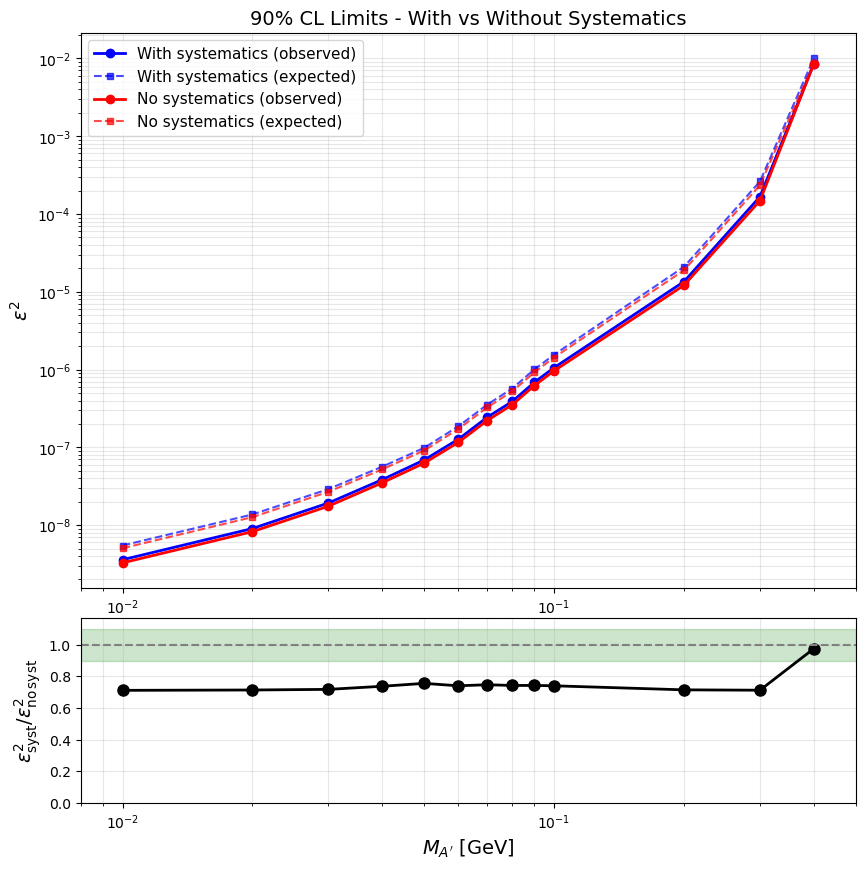

In [14]:
# Plot with systematics and without 
observed_no_syst = df_results_no_syst['epsilon_squared_exp'].values
ratio = paul_observed/observed_no_syst


fig, ax = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08})
# With systematics
ax[0].plot(df_results['mass'], df_results['epsilon_squared_obs'], 
        'b-o', lw=2, markersize=6, label='With systematics (observed)')
ax[0].plot(df_results['mass'], df_results['epsilon_squared_exp'], 
        'b--s', lw=1.5, markersize=4, alpha=0.7, label='With systematics (expected)')

# Without systematics
ax[0].plot(df_results_no_syst['mass'], df_results_no_syst['epsilon_squared_obs'], 
        'r-o', lw=2, markersize=6, label='No systematics (observed)')
ax[0].plot(df_results_no_syst['mass'], df_results_no_syst['epsilon_squared_exp'], 
        'r--s', lw=1.5, markersize=4, alpha=0.7, label='No systematics (expected)')

ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel(r'$M_{A^\prime}$ [GeV]', fontsize=14)
ax[0].set_ylabel(r'$\varepsilon^2$', fontsize=14)
ax[0].set_title(r'90% CL Limits - With vs Without Systematics', fontsize=14)
ax[0].legend(fontsize=11, loc='upper left')
ax[0].grid(True, alpha=0.3, which='both')
ax[0].set_xlim(0.008, 0.5)

# Ratio plot
ax[1].plot(paul_mass_gev, ratio, 'ko-', lw=2, markersize=8)
ax[1].axhline(1.0, color='gray', linestyle='--', linewidth=1.5)
ax[1].fill_between([0.008, 0.5], 0.9, 1.1, color='green', alpha=0.2, label='±10%')

ax[1].set_xscale('log')
ax[1].set_xlabel(r'$M_{A^\prime}$ [GeV]', fontsize=14)
ax[1].set_ylabel(r'$\varepsilon^2_{\mathrm{syst}} / \varepsilon^2_{\mathrm{no \/ syst}}$', fontsize=14)
ax[1].set_xlim(0.008, 0.5)
ax[1].set_ylim(0, max(ratio) * 1.2)
ax[1].grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig("/home/paul/Msci/plots/limits_with_vs_without_systematics.png", dpi=300)
plt.show()